In [2]:
# importing required libraries
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
# importing data
chemicals_water = pd.read_csv('/Users/mariajosepena/Desktop/Capstone/Waterbase_data.csv')
chemicals_water.head()

,countryCode,waterBodyIdentifier,waterBodyIdentifierScheme,parameterWaterBodyCategory,observedPropertyDeterminandCode,observedPropertyDeterminandLabel,procedureAnalysedMatrix,resultUom,phenomenonTimeReferenceYear,parameterSamplingPeriod,...,resultNumberOfSitesClass4,resultNumberOfSitesClass5,resultObservationStatus,remarks,metadata_versionId,metadata_beginLifeSpanVersion,metadata_statusCode,metadata_observationStatus,metadata_statements,UID
0,BG,BG096,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,1991,1991-01-01--1991-12-31,...,1.0,1.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,2667
1,FI,FI016,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,2009,2009-01-01--2009-12-31,...,0.0,0.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,QC_LOQ_BELOW_MIN_NONESSENTIAL: Possible LOQ ou...,12234
2,BG,BG3G000000Q010,euGroundWaterBodyCode,GW,EEA_3132-01-2,Dissolved oxygen,W,mg/L,2002,2002-01-01--2002-12-31,...,NaN,NaN,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,4282
3,FI,FI034,eionetGroundWaterBodyCode,GW,EEA_3132-01-2,Dissolved oxygen,W,mg/L,1989,1989-01-01--1989-12-31,...,NaN,NaN,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,NOTE_LEGACY: The resultNumberOfSamples changed...,13263
4,FI,FI016,eionetGroundWaterBodyCode,GW,CAS_14797-65-0,Nitrite,W,mg{NO2}/L,2010,2010-01-01--2010-12-31,...,0.0,0.0,NaN,NaN,http://discomap.eea.europa.eu/data/wisesoe/der...,2015-11-30 00:00:00.000,experimental,U,QC_LOQ_BELOW_MIN_NONESSENTIAL: Possible LOQ ou...,12235


In [4]:
# data exploration 
def perform_eda(df, name=""):
    # name, size, shape
    print(f"Exploratory Data Analysis of {str(name)} ")
    print(f"Size {df.size}")
    print(f"Columns {df.shape[1]}")
    print(f"Records {df.shape[0]}")
    print("="*50)
    
    # top 5 records of data
    print("First Look of Data")
    print(df.head())
    print("="*50)
    
    # getting numerical and categorical columns 
    cat_cols = df.select_dtypes(object).columns
    num_cols = df.select_dtypes(np.number).columns

    # prinitng numerical columns
    print("Dataset has following Numerical columns")
    for i, j in enumerate(num_cols):
        print(f" {i+1}) {j}")

    # printing categorical columns
    print("\n\nDataset has following Categorical columns")
    for i, j in enumerate(cat_cols):
        print(f" {i+1}) {j}")
    
    # printing data type, non null values
    print("="*50)
    print("Information of Data")
    print(df.info())
    print("="*50)
    
    # priniting statistical properties such as mean, median, max, min
    print("Statistical Properties of Data")
    print(df.describe(include="all"))
    print("="*50)

perform_eda(chemicals_water, "Global Water Quality")

Exploratory Data Analysis of Global Water Quality 
Size 727405
Columns 35
Records 20783
First Look of Data
  countryCode waterBodyIdentifier  waterBodyIdentifierScheme  \
0          BG               BG096  eionetGroundWaterBodyCode   
1          FI               FI016  eionetGroundWaterBodyCode   
2          BG      BG3G000000Q010      euGroundWaterBodyCode   
3          FI               FI034  eionetGroundWaterBodyCode   
4          FI               FI016  eionetGroundWaterBodyCode   

  parameterWaterBodyCategory observedPropertyDeterminandCode  \
0                         GW                  CAS_14797-65-0   
1                         GW                  CAS_14797-65-0   
2                         GW                   EEA_3132-01-2   
3                         GW                   EEA_3132-01-2   
4                         GW                  CAS_14797-65-0   

  observedPropertyDeterminandLabel procedureAnalysedMatrix  resultUom  \
0                          Nitrite                

In [5]:
# checking for duplicate Rows
print(chemicals_water[chemicals_water.duplicated()])

Empty DataFrame
Columns: [countryCode, waterBodyIdentifier, waterBodyIdentifierScheme, parameterWaterBodyCategory, observedPropertyDeterminandCode, observedPropertyDeterminandLabel, procedureAnalysedMatrix, resultUom, phenomenonTimeReferenceYear, parameterSamplingPeriod, procedureLOQValue, resultNumberOfSamples, resultQualityNumberOfSamplesBelowLOQ, resultQualityMinimumBelowLOQ, resultMinimumValue, resultQualityMeanBelowLOQ, resultMeanValue, resultQualityMaximumBelowLOQ, resultMaximumValue, resultQualityMedianBelowLOQ, resultMedianValue, resultStandardDeviationValue, resultNumberOfSitesClass1, resultNumberOfSitesClass2, resultNumberOfSitesClass3, resultNumberOfSitesClass4, resultNumberOfSitesClass5, resultObservationStatus, remarks, metadata_versionId, metadata_beginLifeSpanVersion, metadata_statusCode, metadata_observationStatus, metadata_statements, UID]
Index: []

[0 rows x 35 columns]


In [6]:
# checking and handling missing values 
for column in chemicals_water.columns:
    print(f"Null Values in column '{column}' are: ", chemicals_water[column].isnull().sum())

Null Values in column 'countryCode' are:  0
Null Values in column 'waterBodyIdentifier' are:  0
Null Values in column 'waterBodyIdentifierScheme' are:  0
Null Values in column 'parameterWaterBodyCategory' are:  0
Null Values in column 'observedPropertyDeterminandCode' are:  0
Null Values in column 'observedPropertyDeterminandLabel' are:  0
Null Values in column 'procedureAnalysedMatrix' are:  0
Null Values in column 'resultUom' are:  0
Null Values in column 'phenomenonTimeReferenceYear' are:  0
Null Values in column 'parameterSamplingPeriod' are:  238
Null Values in column 'procedureLOQValue' are:  90
Null Values in column 'resultNumberOfSamples' are:  0
Null Values in column 'resultQualityNumberOfSamplesBelowLOQ' are:  82
Null Values in column 'resultQualityMinimumBelowLOQ' are:  18224
Null Values in column 'resultMinimumValue' are:  899
Null Values in column 'resultQualityMeanBelowLOQ' are:  18224
Null Values in column 'resultMeanValue' are:  7
Null Values in column 'resultQualityMax

In [7]:
# dropping missing values 
chemicals_clean = chemicals_water.dropna(subset=[
    'countryCode',
    'observedPropertyDeterminandLabel',
    'phenomenonTimeReferenceYear',
    'resultMeanValue'
])

# filtering years >=2000 for recent water quality data
chemicals_clean = chemicals_clean[
    chemicals_clean['phenomenonTimeReferenceYear'] >= 2000
]

chemicals = chemicals_clean[[
    'countryCode',
    'observedPropertyDeterminandLabel',
    'phenomenonTimeReferenceYear',
    'resultMeanValue'
]]

# exploratory data analysis 
perform_eda(chemicals, "Cleaned Water Chemical Data")


Exploratory Data Analysis of Cleaned Water Chemical Data 
Size 59872
Columns 4
Records 14968
First Look of Data
  countryCode observedPropertyDeterminandLabel  phenomenonTimeReferenceYear  \
1          FI                          Nitrite                         2009   
2          BG                 Dissolved oxygen                         2002   
4          FI                          Nitrite                         2010   
7          BG                          Nitrite                         2001   
8          FI                 Dissolved oxygen                         2004   

   resultMeanValue  
1           0.0016  
2           6.9100  
4           0.0016  
7           0.0720  
8           8.9300  
Dataset has following Numerical columns
 1) phenomenonTimeReferenceYear
 2) resultMeanValue


Dataset has following Categorical columns
 1) countryCode
 2) observedPropertyDeterminandLabel
Information of Data
<class 'pandas.core.frame.DataFrame'>
Index: 14968 entries, 1 to 20782
Data co

In [8]:
# checking for Data Integrity
# 1- Checking for Value column
print("*"*100)
print(chemicals['resultMeanValue'].head())
chemicals.loc[:, 'resultMeanValue'] = chemicals['resultMeanValue'].astype(float)
print("Counting the number of zeros in 'resultMeanValue' column: ",  (chemicals['resultMeanValue'] == 0.00).sum())
print('Zero can mean chemical concentration is very low.')
print("*"*100)

# 2- Checking for Year Column
print("*"*100)
print(chemicals['phenomenonTimeReferenceYear'].head())
# Because of String literlas in column we have to replace them with year 2022
val = (chemicals['phenomenonTimeReferenceYear'] == 'Latest available year').sum()
print('Total of', val, 'strings replaced with 2022.')
chemicals.loc[:, 'phenomenonTimeReferenceYear'] = \
    chemicals['phenomenonTimeReferenceYear'].replace('Latest available year', 2022)

****************************************************************************************************
1    0.0016
2    6.9100
4    0.0016
7    0.0720
8    8.9300
Name: resultMeanValue, dtype: float64
Counting the number of zeros in 'resultMeanValue' column:  0
Zero can mean chemical concentration is very low.
****************************************************************************************************
****************************************************************************************************
1    2009
2    2002
4    2010
7    2001
8    2004
Name: phenomenonTimeReferenceYear, dtype: int64
Total of 0 strings replaced with 2022.


In [9]:
# dropping missing values in selected columns
water_clean = chemicals.dropna(subset=[
    'countryCode',
    'observedPropertyDeterminandLabel',
    'phenomenonTimeReferenceYear',
    'resultMeanValue'
])

# renaming 'countryCode' to respective country name
countries = {
    'AT': 'Austria',
    'BE': 'Belgium',
    'BG': 'Bulgaria',
    'HR': 'Croatia',
    'CY': 'Cyprus',
    'CZ': 'Czech Republic',
    'DK': 'Denmark',
    'EE': 'Estonia',
    'FI': 'Finland',
    'FR': 'France',
    'DE': 'Germany',
    'EL': 'Greece',
    'GR': 'Greece',
    'HU': 'Hungary',
    'IE': 'Ireland',
    'IT': 'Italy',
    'LV': 'Latvia',
    'LI': 'Liechtenstein',
    'LU': 'Luxembourg',
    'MT': 'Malta',
    'NL': 'Netherlands',
    'PL': 'Poland',
    'PT': 'Portugal',
    'RO': 'Romania',
    'SK': 'Slovakia',
    'SI': 'Slovenia',
    'ES': 'Spain',
    'SE': 'Sweden',
    'NO': 'Norway',
    'CH': 'Switzerland',
    'ME': 'Montenegro',
    'TR': 'Turkey',
    'AL': 'Albania'
}
water_clean['countryCode'] = water_clean['countryCode'].replace(countries)

# renaming column 'countryCode' to 'Country'
water_clean.rename(columns={'countryCode': 'Country'}, inplace=True)

# new look at data
print(water_clean.head())
water_clean.shape

    Country observedPropertyDeterminandLabel  phenomenonTimeReferenceYear  \
1   Finland                          Nitrite                         2009   
2  Bulgaria                 Dissolved oxygen                         2002   
4   Finland                          Nitrite                         2010   
7  Bulgaria                          Nitrite                         2001   
8   Finland                 Dissolved oxygen                         2004   

   resultMeanValue  
1           0.0016  
2           6.9100  
4           0.0016  
7           0.0720  
8           8.9300  


(14968, 4)

In [21]:
# saving clean dataset
water_clean.to_csv('water_cleaned.csv', index=False)

In [22]:
# filtering data for The Netherlands
nl_water = water_clean[water_clean['Country'] == 'Netherlands']

Total unique values are:  2 


Category	Value

observedPropertyDeterminandLabel
Ammonium    136
Nitrate     136
Name: count, dtype: int64


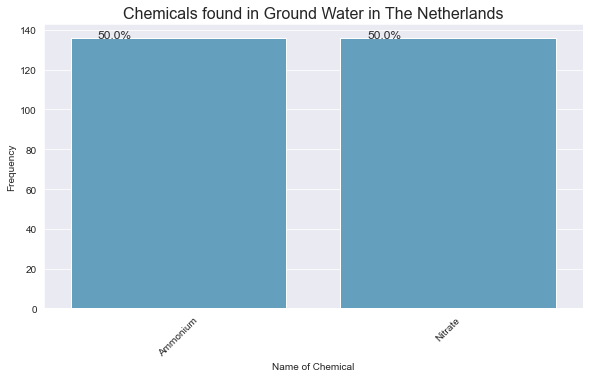

In [12]:
# univariate Analysis
def plot_category_dist(feature, title="", limited=False, n=10):
    print("Total unique values are: ", len(feature.value_counts()), "\n\n")
    print("Category\tValue\n")
    if limited:
        data = feature.value_counts()[0:n]
    else:
        data = feature.value_counts()
    print(data)
    categories_num = len(data)
    # plotting chemicals found in water bar-plot 
    sns.set_style('darkgrid')
    plt.figure(figsize=(16,5))
    plt.subplot(1,2,1)
    plt.title(title, fontsize=16)
    plt.xlabel("Name of Chemical")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plot = sns.barplot(x=data.index, y=data.values, edgecolor="white", color=sns.color_palette("icefire")[0])

    total = len(feature)
    for p in plot.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.3
        y = p.get_y() + p.get_height()
        plot.annotate(percentage, (x, y), size = 12)

plot_category_dist(nl_water['observedPropertyDeterminandLabel'],f"Chemicals found in Ground Water in The Netherlands")

In [13]:
import plotly.express as px

def plot_chemical_trend(df, country, chemical, min_year=2000):
    """
    Plots interactive bar chart of total yearly concentration of a chemical
    for a selected country from a cleaned dataset.
    """
    # filtering data
    subset = df[
        (df['Country'] == country) & 
        (df['observedPropertyDeterminandLabel'] == chemical) &
        (df['phenomenonTimeReferenceYear'] >= min_year)
    ]

    # group by year and sum concentrations
    grouped = subset.groupby('phenomenonTimeReferenceYear')['resultMeanValue'].sum().reset_index()

    # making plot
    fig = px.bar(
        grouped,
        x='phenomenonTimeReferenceYear',
        y='resultMeanValue',
        title=f'{chemical} Concentration Over Time in {country}',
        labels={
            'phenomenonTimeReferenceYear': 'Year',
            'resultMeanValue': 'Total Concentration'
        },
        text_auto='.2s'
    )

    fig.update_traces(marker_color='darkcyan', textposition='outside')
    fig.update_layout(title_font_size=18, xaxis_tickangle=-45, bargap=0.2, margin=dict(t=100))
    fig.show()

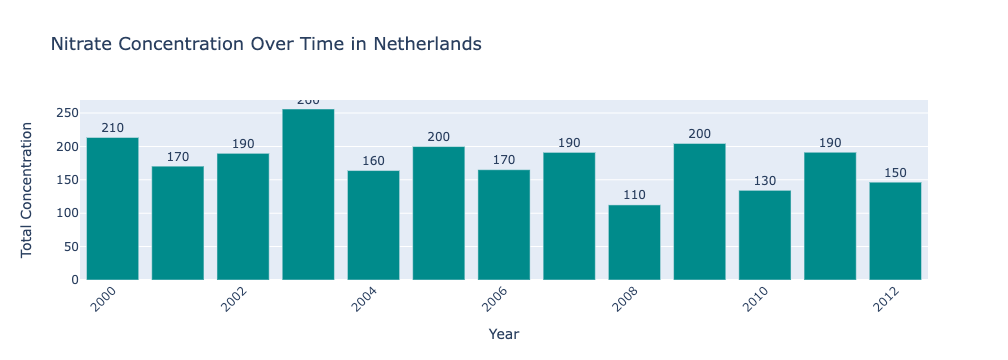

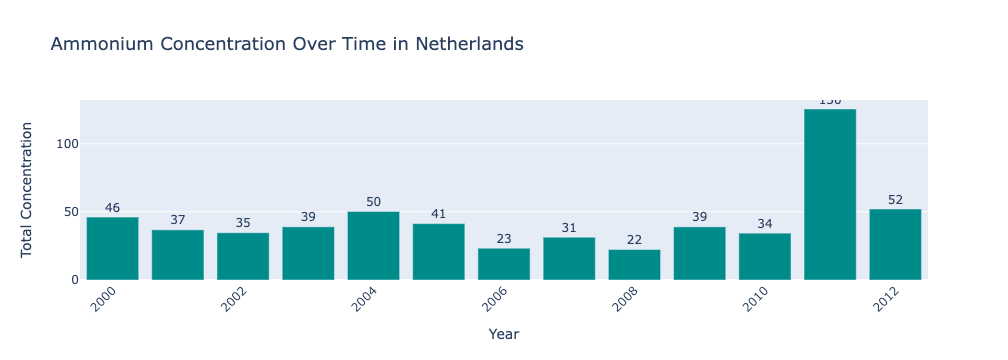

In [23]:
plot_chemical_trend(
    df=water_clean,
    country='Netherlands',
    chemical='Nitrate',
    min_year=2000
)

plot_chemical_trend(
    df=water_clean,
    country='Netherlands',
    chemical='Ammonium',
    min_year=2000
)

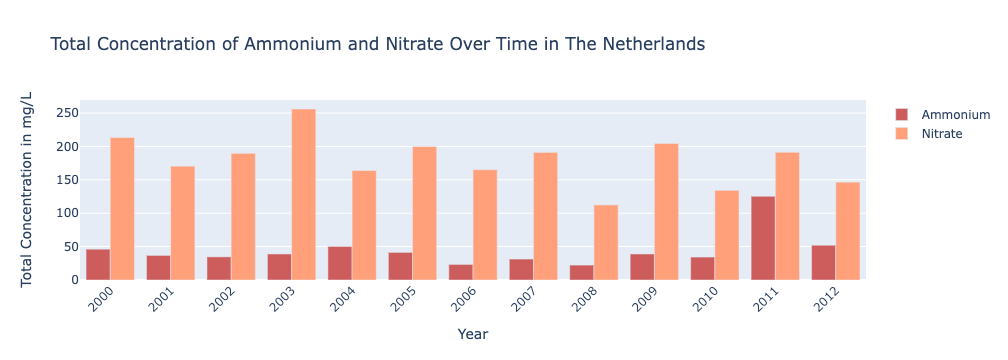

In [39]:
# https://plotly.com/python/bar-charts/

import plotly.graph_objects as go

# filtering data for The Netherlands
nl_water = water_clean[water_clean['Country'] == 'Netherlands']

grouped = nl_water.groupby(['phenomenonTimeReferenceYear', 'observedPropertyDeterminandLabel'])['resultMeanValue'].sum().reset_index()
pivoted = grouped.pivot(index='phenomenonTimeReferenceYear', columns='observedPropertyDeterminandLabel', values='resultMeanValue').fillna(0)

# sort years
pivoted = pivoted.sort_index()

# data for plotting
years = pivoted.index.astype(str)  # convert to string for plotly x-axis
ammonium = pivoted['Ammonium'] if 'Ammonium' in pivoted else [0]*len(years)
nitrate = pivoted['Nitrate'] if 'Nitrate' in pivoted else [0]*len(years)

# making plot
fig = go.Figure()
fig.add_trace(go.Bar(
    x=years,
    y=ammonium,
    name='Ammonium',
    marker_color='indianred'
))
fig.add_trace(go.Bar(
    x=years,
    y=nitrate,
    name='Nitrate',
    marker_color='lightsalmon'
))

fig.update_layout(
    title='Total Concentration of Ammonium and Nitrate Over Time in The Netherlands',
    xaxis_title='Year',
    yaxis_title='Total Concentration in mg/L',
    barmode='group',
    xaxis_tickangle=-45
)
fig.show()

In [40]:
print(water_clean.columns)

Index(['Country', 'observedPropertyDeterminandLabel',
       'phenomenonTimeReferenceYear', 'resultMeanValue'],
      dtype='object')


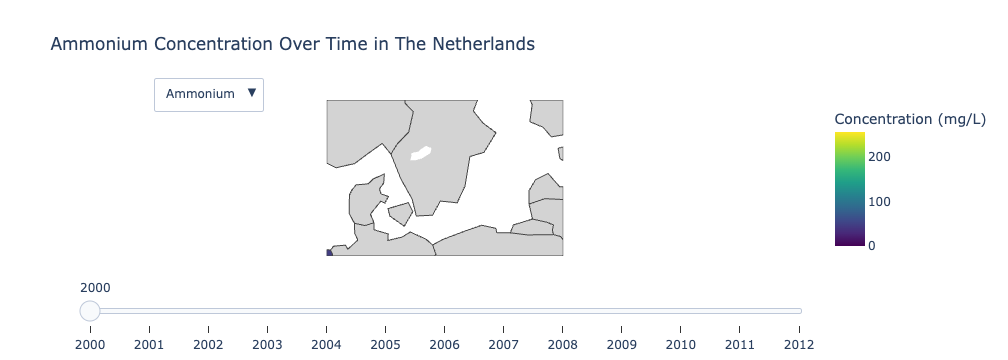

In [41]:
import plotly.graph_objects as go

# filtering data for the Netherlands
nl_water = water_clean[water_clean['Country'] == 'Netherlands']

# grouping and pivoting the data for Nitrate and Ammonium (chemicals found in GW)
grouped = nl_water.groupby(['phenomenonTimeReferenceYear', 'observedPropertyDeterminandLabel'])['resultMeanValue'].sum().reset_index()
pivoted = grouped.pivot(index='phenomenonTimeReferenceYear', columns='observedPropertyDeterminandLabel', values='resultMeanValue').fillna(0)

# sorting years
pivoted = pivoted.sort_index()

# create frames (years) for animation throughout time
frames = []
for year in pivoted.index:
    # creating a frame for each year, filtered by selected chemical
    frame_data = grouped[grouped['phenomenonTimeReferenceYear'] == year]
    frame = go.Choropleth(
        locations=['Netherlands'],  # map limited to the Nethelrnalds
        z=frame_data['resultMeanValue'],
        colorbar_title="Concentration (mg/L)",
        colorscale='Viridis',
        zmin=0, zmax=pivoted.max().max(),
        hovertemplate="%{location}: %{z:.2f} mg/L<extra></extra>",
        showscale=True,
        locationmode='country names',
    )
    frames.append(go.Frame(data=[frame], name=str(year)))

# map for concentration of Ammonium
initial_chemical = 'Ammonium'
fig = go.Figure(data=go.Choropleth(
    locations=['Netherlands'],
    z=pivoted[initial_chemical],
    colorbar_title="Concentration (mg/L)",
    colorscale='Viridis',
    zmin=0, zmax=pivoted.max().max(),
    hovertemplate="%{location}: %{z:.2f} mg/L<extra></extra>",
    showscale=True,
    locationmode='country names',
))

fig.frames = frames

# creating buttons for cdropdown of chemicals 
dropdown_buttons = [
    dict(
        label=chem,
        method='animate',
        args=[
            [str(year) for year in pivoted.index],
            {
                'frame': {'duration': 500, 'redraw': True},
                'transition': {'duration': 300},
                'mode': 'immediate',
                'frame': {'duration': 500}
            }
        ]
    ) for chem in pivoted.columns
]

# dropdown to choose between Nitrate or Ammonium
fig.update_layout(
    updatemenus=[
        {
            'buttons': dropdown_buttons,
            'direction': 'down',
            'showactive': True,
            'x': 0.1,
            'xanchor': 'left',
            'y': 1.15,
            'yanchor': 'top'
        }
    ],
    geo=dict(
        scope='europe',
        projection_type='natural earth',
        showcoastlines=True,
        showframe=False,
        landcolor='lightgrey',
        projection_scale=6,
        showcountries=True,
    ),
    title=f'{initial_chemical} Concentration Over Time in The Netherlands',
    coloraxis_colorbar=dict(title="Concentration (mg/L)"),
)

fig.update_layout(
    sliders=[{
        'steps': [
            {
                'args': [
                    [str(year)],
                    {
                        'frame': {'duration': 500, 'redraw': True},
                        'transition': {'duration': 300}
                    }
                ],
                'label': str(year),
                'method': 'animate',
            }
            for year in pivoted.index
        ]
    }]
)

fig.show()
